#step 1 : choose a data set
## Student depression dataset



# Step 2 – Describe Your Dataset

##What is your data source?

###1. What is your data source?
My data source is the Student Depression Dataset, provided as a CSV file. The dataset contains information about students and different factors related to their academic, personal, financial, and mental well-being.
###2. Why did you choose it?
I chose this dataset because student mental health is an important topic. The dataset allows us to analyze factors such as academic pressure, sleep, study satisfaction, financial stress, and family history of mental illness and examine their relationship with the depression indicator.
###3. What information does it contain?
The dataset contains 27,901 records and 18 columns. Some of the important information includes:
Student ID
Gender
Age
City
Profession
Academic Pressure
Work Pressure
CGPA
Study Satisfaction
Job Satisfaction
Sleep Duration
Dietary Habits
Degree
Suicidal Thoughts
Work/Study Hours
Financial Stress
Family History of Mental Illness
Depression indicator
###4. Is it structured, semi-structured, or unstructured?
It is structured data because the information is organized into rows and columns, with each column representing a specific attribute.
###5. What format is the data?
The data is in CSV (Comma-Separated Values) format. CSV is a commonly used format for storing and exchanging tabular data and can easily be processed using Python, Pandas, Excel, and SQL.
###6. How frequently is the data updated?
The dataset is a static dataset, so it does not appear to be automatically updated on a regular schedule. It represents the data available in the provided CSV file. If a newer version is released by the dataset provider, it would need to be downloaded separately.


# STEP 3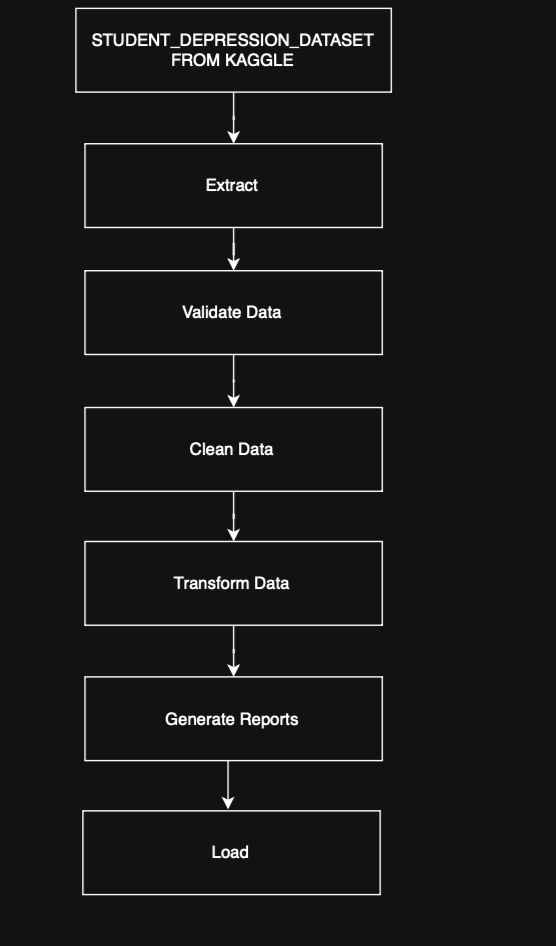

#Step 5 – Build the Extract Function

In [ ]:
import pandas as pd
import numpy as np
import os

In [ ]:
def extract():
    # 1. Connect to / read the chosen data source
    file_path = "/content/Miniproject/raw_data"
    data = pd.read_csv('/content/Miniproject/raw_data/Student Depression Dataset.csv')

    # 2. Display number of records
    print("Number of records:",(data.shape[0]))

    # 3. Display number of columns
    print("Number of columns:", (data.shape[1]))
    return data

In [ ]:
extract()

Number of records: 27901
Number of columns: 18


,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27896,140685,Female,27.0,Surat,Student,5.0,0.0,5.75,5.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,7.0,1.0,Yes,0
27897,140686,Male,27.0,Ludhiana,Student,2.0,0.0,9.40,3.0,0.0,Less than 5 hours,Healthy,MSc,No,0.0,3.0,Yes,0
27898,140689,Male,31.0,Faridabad,Student,3.0,0.0,6.61,4.0,0.0,5-6 hours,Unhealthy,MD,No,12.0,2.0,No,0
27899,140690,Female,18.0,Ludhiana,Student,5.0,0.0,6.88,2.0,0.0,Less than 5 hours,Healthy,Class 12,Yes,10.0,5.0,No,1


#Step 6 – Build the Transform Function

In [ ]:
def transform(stud_dep):
 # 1. Remove duplicate records
  stud_dep = stud_dep.drop_duplicates()

 # 2. Handle missing values
  stud_dep = stud_dep.dropna()

 # 3. Remove unwanted column
  if "id" in stud_dep.columns:
      stud_dep = stud_dep.drop(columns=["id"])

# 4. Standardize column names
  stud_dep.columns = stud_dep.columns.str.strip().str.lower().str.replace(" ", "_")

# 5. Standardize text values
  for col in stud_dep.select_dtypes(include="object").columns:
        stud_dep[col] = stud_dep[col].str.strip()
# 6. Remove invalid age values
  if "age" in stud_dep.columns:
        stud_dep = stud_dep[(stud_dep["age"] >= 15) & (stud_dep["age"] <= 100)]

# 7. Sort records by age
  if "age" in stud_dep.columns:
        stud_dep = stud_dep.sort_values(by="age")

# 8. Create a depression category
  if "depression" in stud_dep.columns:
        stud_dep["depression_category"] = stud_dep["depression"].map({
            0: "No",
            1: "Yes"
        })
        return stud_dep



#Step 7 – Generate Reports and
#step 8 load

In [ ]:
import os

def load(cleaned_data):
  # Create reports directory if it doesn't exist
  reports_dir = '/content/Miniproject/reports'
  os.makedirs(reports_dir, exist_ok=True)

# 1. Complete cleaned dataset
  cleaned_data.to_csv(os.path.join(reports_dir, 'complete_cleaned_dataset.csv'), index=False)
  print(f"Report saved: {os.path.join(reports_dir, 'complete_cleaned_dataset.csv')}")

# 2. Top 10 records
  top_10_records = cleaned_data.head(10)
  top_10_records.to_csv(os.path.join(reports_dir, 'top_10_records.csv'), index=False)
  print(f"Report saved: {os.path.join(reports_dir, 'top_10_records.csv')}")

# 3. Summary statistics
  summary_stats = cleaned_data.describe()
  summary_stats.to_csv(os.path.join(reports_dir, 'summary_stats.csv'), index=False)

  print(f"Report saved: {os.path.join(reports_dir, 'summary_stats.csv')}")




#Step 9 – Build the Pipeline

In [ ]:
def run_pipeline():
  raw_data = extract()
  cleaned_data = transform(raw_data)
  load(cleaned_data)

In [ ]:
run_pipeline()

Number of records: 27901
Number of columns: 18
Report saved: /content/Miniproject/reports/complete_cleaned_dataset.csv
Report saved: /content/Miniproject/reports/top_10_records.csv
Report saved: /content/Miniproject/reports/summary_stats.csv


# data preprocessing cleaned data

In [ ]:
import pandas as pd

In [ ]:
df_data = pd.read_csv("/content/Miniproject/reports/complete_cleaned_dataset.csv")

In [ ]:
df_data.head()

,gender,age,city,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,have_you_ever_had_suicidal_thoughts_?,work/study_hours,financial_stress,family_history_of_mental_illness,depression,depression_category
0,Female,18.0,Rajkot,Student,5.0,0.0,8.91,3.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,10.0,2.0,Yes,1,Yes
1,Male,18.0,Surat,Student,5.0,0.0,7.83,5.0,0.0,More than 8 hours,Moderate,Class 12,Yes,8.0,5.0,Yes,1,Yes
2,Male,18.0,Vasai-Virar,Student,4.0,0.0,8.70,5.0,0.0,Less than 5 hours,Moderate,Class 12,Yes,2.0,4.0,No,1,Yes
3,Male,18.0,Varanasi,Student,4.0,0.0,9.19,5.0,0.0,7-8 hours,Healthy,Class 12,Yes,12.0,3.0,Yes,1,Yes
4,Female,18.0,Kanpur,Student,1.0,0.0,7.27,5.0,0.0,Less than 5 hours,Healthy,Class 12,No,7.0,5.0,No,1,Yes


In [ ]:
df_data.shape

(27898, 18)

In [ ]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27898 entries, 0 to 27897
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 27898 non-null  object 
 1   age                                    27898 non-null  float64
 2   city                                   27898 non-null  object 
 3   profession                             27898 non-null  object 
 4   academic_pressure                      27898 non-null  float64
 5   work_pressure                          27898 non-null  float64
 6   cgpa                                   27898 non-null  float64
 7   study_satisfaction                     27898 non-null  float64
 8   job_satisfaction                       27898 non-null  float64
 9   sleep_duration                         27898 non-null  object 
 10  dietary_habits                         27898 non-null  object 
 11  de

In [ ]:
# Missing values

df_data.isna().sum()

,0
gender,0
age,0
city,0
profession,0
academic_pressure,0
work_pressure,0
cgpa,0
study_satisfaction,0
job_satisfaction,0
sleep_duration,0


In [ ]:
df_data.duplicated().sum()


np.int64(0)

In [ ]:
# outlier detection

import matplotlib.pyplot as plt
import seaborn as sns

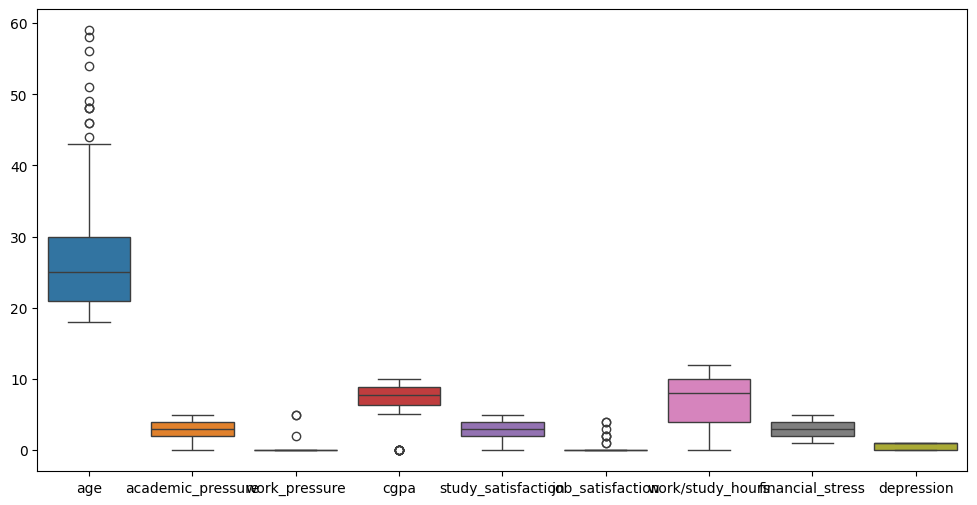

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(df_data)
plt.show()

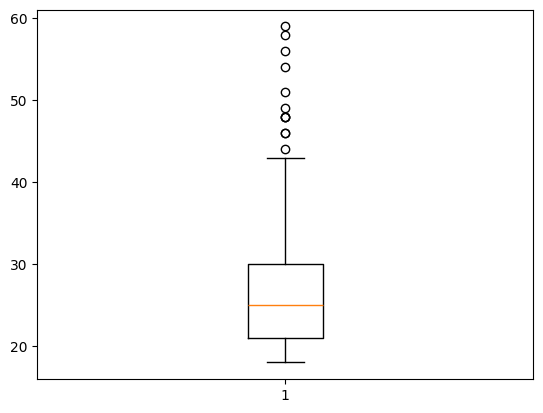

In [ ]:
plt.boxplot(df_data['age'])
plt.show()

In [ ]:
q1 =df_data['age'].quantile(0.25)
q2 =df_data['age'].quantile(0.5)
q3 =df_data['age'].quantile(0.75)

In [ ]:
print(f'Q1 ={q1}\nQ2 ={q2}\nQ3 ={q3}')
IQR = q3 -q1
up_lim = q3+(1.5*IQR)
low_lim = q1 -(1.5*IQR)
print(f'Iqr = {IQR} \n UPPER LIMIT = {up_lim} \n LOWER LIMIT = {low_lim}')

Q1 =21.0
Q2 =25.0
Q3 =30.0
Iqr = 9.0 
 UPPER LIMIT = 43.5 
 LOWER LIMIT = 7.5


In [ ]:
df_data.loc[df_data['age'] > up_lim, 'age'] = up_lim
df_data.loc[df_data['age'] < low_lim, 'age'] = low_lim

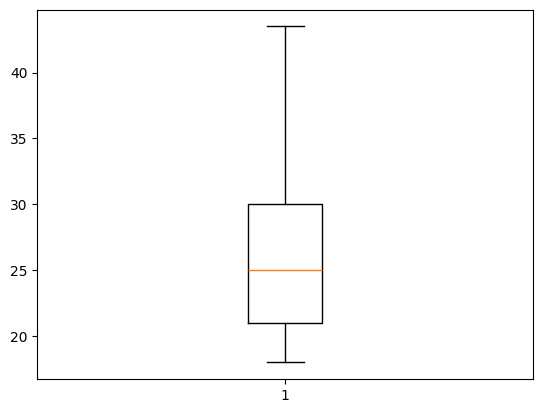

In [ ]:
plt.boxplot(df_data['age'])
plt.show()

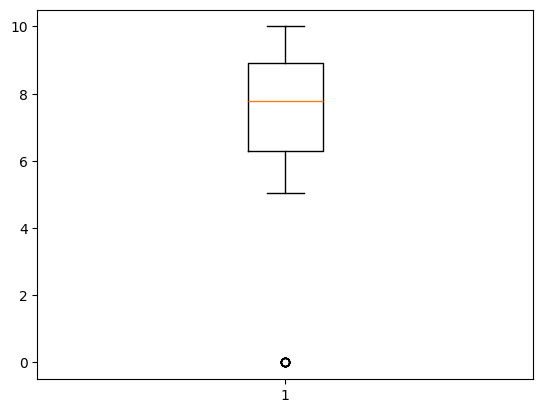

In [ ]:
plt.boxplot(df_data['cgpa'])
plt.show()

In [ ]:
q1 =df_data['cgpa'].quantile(0.25)
q2 =df_data['cgpa'].quantile(0.5)
q3 =df_data['cgpa'].quantile(0.75)

In [ ]:
print(f'Q1 ={q1}\nQ2 ={q2}\nQ3 ={q3}')
IQR = q3 -q1
up_lim = q3+(1.5*IQR)
low_lim = q1 -(1.5*IQR)
print(f'Iqr = {IQR} \n UPPER LIMIT = {up_lim} \n LOWER LIMIT = {low_lim}')

Q1 =6.29
Q2 =7.77
Q3 =8.92
Iqr = 2.63 
 UPPER LIMIT = 12.865 
 LOWER LIMIT = 2.345


In [ ]:
df_data.loc[df_data['cgpa'] > up_lim, 'cgpa'] = up_lim
df_data.loc[df_data['cgpa'] < low_lim, 'cgpa'] = low_lim

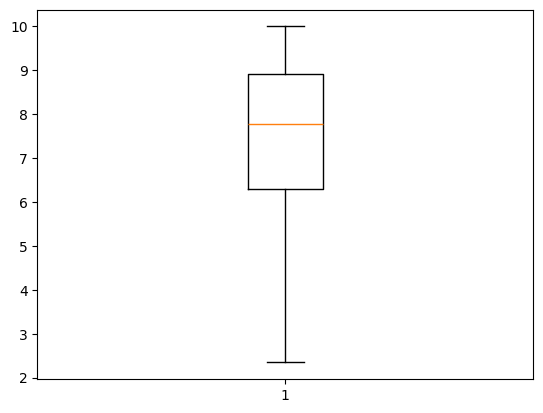

In [ ]:
plt.boxplot(df_data['cgpa'])
plt.show()

#Encoding

In [ ]:
df_data.dtypes

,0
gender,object
age,float64
city,object
profession,object
academic_pressure,float64
work_pressure,float64
cgpa,float64
study_satisfaction,float64
job_satisfaction,float64
sleep_duration,object


In [ ]:
df_data.head()

,gender,age,city,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,have_you_ever_had_suicidal_thoughts_?,work/study_hours,financial_stress,family_history_of_mental_illness,depression,depression_category
0,Female,18.0,Rajkot,Student,5.0,0.0,8.91,3.0,0.0,5-6 hours,Unhealthy,Class 12,Yes,10.0,2.0,Yes,1,Yes
1,Male,18.0,Surat,Student,5.0,0.0,7.83,5.0,0.0,More than 8 hours,Moderate,Class 12,Yes,8.0,5.0,Yes,1,Yes
2,Male,18.0,Vasai-Virar,Student,4.0,0.0,8.70,5.0,0.0,Less than 5 hours,Moderate,Class 12,Yes,2.0,4.0,No,1,Yes
3,Male,18.0,Varanasi,Student,4.0,0.0,9.19,5.0,0.0,7-8 hours,Healthy,Class 12,Yes,12.0,3.0,Yes,1,Yes
4,Female,18.0,Kanpur,Student,1.0,0.0,7.27,5.0,0.0,Less than 5 hours,Healthy,Class 12,No,7.0,5.0,No,1,Yes


In [ ]:
df_data['city'].unique()

array(['Rajkot', 'Surat', 'Vasai-Virar', 'Varanasi', 'Kanpur', 'Srinagar',
       'Indore', 'Hyderabad', 'Bangalore', 'Lucknow', 'Agra', 'Vadodara',
       'Nagpur', 'Nashik', 'Ludhiana', 'Thane', 'Bhopal', 'Patna',
       'Meerut', 'Ahmedabad', 'Delhi', 'Kolkata', 'Kalyan',
       'Visakhapatnam', 'Pune', 'Mumbai', 'Ghaziabad', 'Chennai',
       'Faridabad', 'Bhavna', 'Jaipur', 'Mira', 'Reyansh', 'Kibara',
       'Vaanya', 'Rashi', 'Harsh', '3.0', 'Nalini', 'ME', 'M.Com',
       'Khaziabad', 'Saanvi', 'City', 'Nandini', 'Gaurav', 'Harsha',
       'M.Tech', 'Less Delhi', 'Less than 5 Kalyan', 'Nalyan', 'Mihir'],
      dtype=object)

In [ ]:
df_data['dietary_habits'].unique()

array(['Unhealthy', 'Moderate', 'Healthy', 'Others'], dtype=object)

In [ ]:
df_data['degree'].unique()

array(['Class 12', 'B.Ed', 'Others', 'MSc', 'BA', 'MA', 'B.Tech', 'BCA',
       'MCA', 'M.Com', 'M.Tech', 'BSc', 'BHM', 'B.Arch', 'M.Pharm',
       'MBBS', 'BE', 'B.Com', 'M.Ed', 'MBA', 'BBA', 'B.Pharm', 'MHM',
       'LLB', 'PhD', 'ME', 'MD', 'LLM'], dtype=object)

In [ ]:
df_data['sleep_duration'].unique()

array(['5-6 hours', 'More than 8 hours', 'Less than 5 hours', '7-8 hours',
       'Others'], dtype=object)

In [ ]:
cat_cols = df_data.select_dtypes(include =['object'])

In [ ]:
cat_cols

,gender,city,profession,sleep_duration,dietary_habits,degree,have_you_ever_had_suicidal_thoughts_?,family_history_of_mental_illness,depression_category
0,Female,Rajkot,Student,5-6 hours,Unhealthy,Class 12,Yes,Yes,Yes
1,Male,Surat,Student,More than 8 hours,Moderate,Class 12,Yes,Yes,Yes
2,Male,Vasai-Virar,Student,Less than 5 hours,Moderate,Class 12,Yes,No,Yes
3,Male,Varanasi,Student,7-8 hours,Healthy,Class 12,Yes,Yes,Yes
4,Female,Kanpur,Student,Less than 5 hours,Healthy,Class 12,No,No,Yes
...,...,...,...,...,...,...,...,...,...
27893,Female,Bhopal,Student,Less than 5 hours,Moderate,MBBS,Yes,Yes,No
27894,Male,Agra,Student,More than 8 hours,Unhealthy,B.Ed,Yes,Yes,No
27895,Female,Ludhiana,Student,5-6 hours,Unhealthy,BSc,No,Yes,No
27896,Female,Chennai,Student,7-8 hours,Healthy,Class 12,No,No,No


In [ ]:
frequency = df_data['city'].value_counts()

df_data['city'] = df_data['city'].map(frequency)
print(df_data['city'])

0         816
1        1078
2        1290
3         684
4         609
         ... 
27893     934
27894    1094
27895    1111
27896     885
27897     547
Name: city, Length: 27898, dtype: int64


In [ ]:
frequency1 = df_data['profession'].value_counts()

df_data['profession'] = df_data['profession'].map(frequency1)
print(df_data['profession'])

0        27867
1        27867
2        27867
3        27867
4        27867
         ...  
27893    27867
27894    27867
27895    27867
27896    27867
27897    27867
Name: profession, Length: 27898, dtype: int64


In [ ]:
df_data.dtypes

,0
gender,object
age,float64
city,int64
profession,int64
academic_pressure,float64
work_pressure,float64
cgpa,float64
study_satisfaction,float64
job_satisfaction,float64
sleep_duration,object


In [ ]:
# ordinal encoder
from sklearn.preprocessing import OrdinalEncoder
encoder= OrdinalEncoder(
    categories=[['Class 12', 'BA', 'BBA', 'BCA', 'B.Com', 'BSc',
                 'BHM', 'B.Pharm', 'B.Arch', 'B.Tech', 'BE', 'B.Ed',
                 'LLB', 'MBBS', 'MA', 'MBA', 'MCA', 'M.Com', 'MSc',
                 'MHM', 'M.Pharm', 'M.Tech', 'ME', 'M.Ed', 'LLM',
                 'MD', 'PhD', 'Others']]
)
df_data['degree']=encoder.fit_transform(df_data[['degree']])

In [ ]:
df_data.dtypes

,0
gender,object
age,float64
city,int64
profession,int64
academic_pressure,float64
work_pressure,float64
cgpa,float64
study_satisfaction,float64
job_satisfaction,float64
sleep_duration,object


In [ ]:

# encoder1= OrdinalEncoder(
#     categories=[['More than 8 hours', '7-8 hours', '5-6 hours',
#                  'Less than 5 hours', 'Others']]
# )
# df_data['sleep_duration']=encoder.fit_transform(df_data[['sleep_duration']])

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

# Wrap the descending list in an outer list [ ]
sleep_categories = [
    ['More than 8 hours', '7-8 hours', '5-6 hours', 'Less than 5 hours', 'Others']
]

# Initialize the encoder with the correct 2D categories shape
encoder = OrdinalEncoder(categories=sleep_categories)

# Fit and transform your column
df_data['sleep_duration'] = encoder.fit_transform(df_data[['sleep_duration']])


In [ ]:
df_data

,gender,age,city,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,have_you_ever_had_suicidal_thoughts_?,work/study_hours,financial_stress,family_history_of_mental_illness,depression,depression_category
0,Female,18.0,816,27867,5.0,0.0,8.91,3.0,0.0,2.0,Unhealthy,0.0,Yes,10.0,2.0,Yes,1,Yes
1,Male,18.0,1078,27867,5.0,0.0,7.83,5.0,0.0,0.0,Moderate,0.0,Yes,8.0,5.0,Yes,1,Yes
2,Male,18.0,1290,27867,4.0,0.0,8.70,5.0,0.0,3.0,Moderate,0.0,Yes,2.0,4.0,No,1,Yes
3,Male,18.0,684,27867,4.0,0.0,9.19,5.0,0.0,1.0,Healthy,0.0,Yes,12.0,3.0,Yes,1,Yes
4,Female,18.0,609,27867,1.0,0.0,7.27,5.0,0.0,3.0,Healthy,0.0,No,7.0,5.0,No,1,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27893,Female,43.5,934,27867,2.0,0.0,8.26,3.0,0.0,3.0,Moderate,13.0,Yes,5.0,5.0,Yes,0,No
27894,Male,43.5,1094,27867,5.0,0.0,9.60,2.0,0.0,0.0,Unhealthy,11.0,Yes,9.0,3.0,Yes,0,No
27895,Female,43.5,1111,27867,3.0,0.0,7.94,5.0,0.0,2.0,Unhealthy,5.0,No,1.0,5.0,Yes,0,No
27896,Female,43.5,885,27867,4.0,0.0,8.58,1.0,0.0,1.0,Healthy,0.0,No,4.0,4.0,No,0,No


In [ ]:
df_data['dietary_habits'].unique()

array(['Unhealthy', 'Moderate', 'Healthy', 'Others'], dtype=object)

In [ ]:
diet_categories = [
    ['Unhealthy', 'Moderate', 'Healthy', 'Others']
]

# Initialize the encoder with the correct 2D categories shape
encoder = OrdinalEncoder(categories=diet_categories )

# Fit and transform your column
df_data['dietary_habits'] = encoder.fit_transform(df_data[['dietary_habits']])

In [ ]:
# label encoder

from sklearn.preprocessing import LabelEncoder

binary_cols = ['gender','have_you_ever_had_suicidal_thoughts_?',
               'family_history_of_mental_illness','depression_category']
le = LabelEncoder()
for col in binary_cols:
    df_data[col] = le.fit_transform(df_data[col])

In [ ]:
df_data.dtypes

,0
gender,int64
age,float64
city,int64
profession,int64
academic_pressure,float64
work_pressure,float64
cgpa,float64
study_satisfaction,float64
job_satisfaction,float64
sleep_duration,float64


# Scaling

In [ ]:
from sklearn.model_selection import train_test_split

y = df_data['depression']
x = df_data.drop('depression',axis=1)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_array = scaler.fit_transform(x_train)
x_test_array = scaler.fit_transform(x_test)

x_train_scaled= pd.DataFrame(x_train_array, columns=x_train.columns, index=x_train.index)
x_test_scaled= pd.DataFrame(x_test_array, columns=x_test.columns, index=x_test.index)



In [ ]:
x_train_scaled

,gender,age,city,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,have_you_ever_had_suicidal_thoughts_?,work/study_hours,financial_stress,family_history_of_mental_illness,depression_category
26046,-1.123438,1.468799,-0.433988,0.034152,-1.552897,-0.008701,-1.230456,-1.432959,-0.014711,-0.540465,0.116924,1.463427,-1.306340,1.304430,-1.485596,1.030393,-1.188485
20525,-1.123438,0.651194,1.392063,0.034152,-0.828041,-0.008701,0.258380,0.036611,-0.014711,-0.540465,0.116924,0.084299,0.765497,-1.932545,0.603950,-0.970504,0.841408
15397,0.890125,0.242391,0.023462,0.034152,0.621672,-0.008701,-1.312410,0.771396,-0.014711,-0.540465,-1.135839,-1.169454,0.765497,0.495187,-0.092565,-0.970504,0.841408
14999,0.890125,0.037990,-0.122772,0.034152,-0.828041,-0.008701,1.535500,0.036611,-0.014711,-1.428624,-1.135839,-0.667953,-1.306340,-0.583805,1.300466,-0.970504,-1.188485
24414,0.890125,1.264397,1.268327,0.034152,0.621672,-0.008701,0.176425,-0.698174,-0.014711,-1.428624,0.116924,0.460425,0.765497,-0.044309,-0.789080,-0.970504,-1.188485
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21575,-1.123438,0.855595,-0.692710,0.034152,-0.103184,-0.008701,0.845718,1.506181,-0.014711,-0.540465,1.369687,1.839552,0.765497,1.034682,1.300466,1.030393,0.841408
5390,-1.123438,-0.984017,0.289683,0.034152,-1.552897,-0.008701,1.405739,0.036611,-0.014711,-0.540465,-1.135839,-0.166452,-1.306340,1.034682,-0.092565,-0.970504,-1.188485
860,0.890125,-1.597220,1.392063,0.034152,-0.103184,-0.008701,-1.367046,0.771396,-0.014711,1.235854,0.116924,-1.169454,0.765497,0.225439,1.300466,-0.970504,0.841408
15795,-1.123438,0.242391,0.240938,0.034152,1.346528,-0.008701,-1.408023,-0.698174,-0.014711,1.235854,-1.135839,1.714177,0.765497,-1.662797,1.300466,-0.970504,0.841408


In [ ]:
x_test_scaled

,gender,age,city,profession,academic_pressure,work_pressure,cgpa,study_satisfaction,job_satisfaction,sleep_duration,dietary_habits,degree,have_you_ever_had_suicidal_thoughts_?,work/study_hours,financial_stress,family_history_of_mental_illness,depression_category
16477,-1.115603,0.237536,0.289439,0.029948,-1.538913,-0.013388,-1.248942,-1.409672,-0.017963,-1.389747,0.125968,-0.049902,0.746270,-0.573173,1.269426,-0.959941,-1.188905
19515,0.896376,0.646753,-1.205074,0.029948,-0.818878,-0.013388,-0.262168,0.793887,-0.017963,1.251529,0.125968,0.199833,0.746270,1.314209,1.269426,-0.959941,0.841110
27257,-1.115603,1.669794,-0.442645,0.029948,-0.098843,-0.013388,-1.208390,0.793887,-0.017963,-1.389747,0.125968,-0.049902,-1.339997,-1.382051,-1.501856,1.041730,-1.188905
8317,0.896376,-0.580897,0.520822,0.029948,1.341226,-0.013388,1.549172,-0.675152,-0.017963,0.371104,-1.129210,-0.049902,0.746270,-1.382051,-0.116215,1.041730,0.841110
9888,0.896376,-0.580897,-1.205074,0.029948,-0.098843,-0.013388,-1.282736,0.059367,-0.017963,1.251529,-1.129210,0.699304,0.746270,1.314209,1.269426,-0.959941,0.841110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9672,0.896376,-0.580897,0.240127,0.029948,-1.538913,-0.013388,-1.194872,1.528406,-0.017963,-0.509321,-1.129210,-0.549373,-1.339997,0.235705,-1.501856,-0.959941,0.841110
23,0.896376,-1.603938,-0.256779,0.029948,0.621191,-0.013388,1.082819,-0.675152,-0.017963,1.251529,0.125968,-1.173712,0.746270,0.774957,1.269426,1.041730,0.841110
21666,-1.115603,0.851361,0.240127,0.029948,0.621191,-0.013388,-0.228374,0.793887,-0.017963,-1.389747,1.381145,0.199833,-1.339997,1.044583,-1.501856,1.041730,-1.188905
22953,0.896376,1.055969,-1.148176,0.029948,-0.098843,-0.013388,0.413705,0.793887,-0.017963,-1.389747,1.381145,-0.799109,-1.339997,0.774957,-1.501856,-0.959941,-1.188905
